**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Cleaned Data:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

# Task 1: Stationarity Check


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data
df = pd.read_csv('weather_clean.csv')
# Data is time-ordered daily observations -> required for stationarity analysis
df['date'] = pd.date_range(start='2022-01-01', periods=len(df))
df.set_index('date', inplace=True)
y  = df['Y'].values.astype(float)
n  = len(y)

dates    = pd.date_range(start='2022-01-01', periods=n, freq='D')
ts       = pd.Series(y, index=dates, name='TAVG (°F)')
train_n  = int(n * 0.8)
ts_train = ts.iloc[:train_n]
ts_test  = ts.iloc[train_n:]
train_vals = ts_train.values
test_vals  = ts_test.values

print(f'Total: {n} | Train: {len(ts_train)} | Test: {len(ts_test)}')

# Helper functions
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100

def chi2_normality_test(residuals, n_bins=20):
    observed, bin_edges = np.histogram(residuals, bins=n_bins)
    expected = np.array([
        len(residuals) * (
            stats.norm.cdf(bin_edges[i+1], residuals.mean(), residuals.std()) -
            stats.norm.cdf(bin_edges[i],   residuals.mean(), residuals.std())
        ) for i in range(n_bins)
    ])
    mask  = expected >= 5
    obs_f = observed[mask]
    exp_f = expected[mask]
    exp_f = exp_f * (obs_f.sum() / exp_f.sum())
    chi2_s, p_val = stats.chisquare(obs_f, f_exp=exp_f)
    return chi2_s, p_val, mask.sum()-1-2, observed, expected, bin_edges

# SMA and Exp Smoothing helpers (required for Tasks 2, 3, 5)
def sma_predict(series, k):
    predicted = np.full(len(series), np.nan)
    for t in range(k, len(series)):
        predicted[t] = np.mean(series[t-k:t])
    return predicted

def exp_smooth_predict(series, alpha):
    pred = np.full(len(series), np.nan)
    pred[0] = series[0]
    for t in range(1, len(series)):
        pred[t] = alpha * series[t-1] + (1 - alpha) * pred[t-1]
    return pred


Total: 1477 | Train: 1181 | Test: 296


## Task 1.1 - Plot the Full Time Series

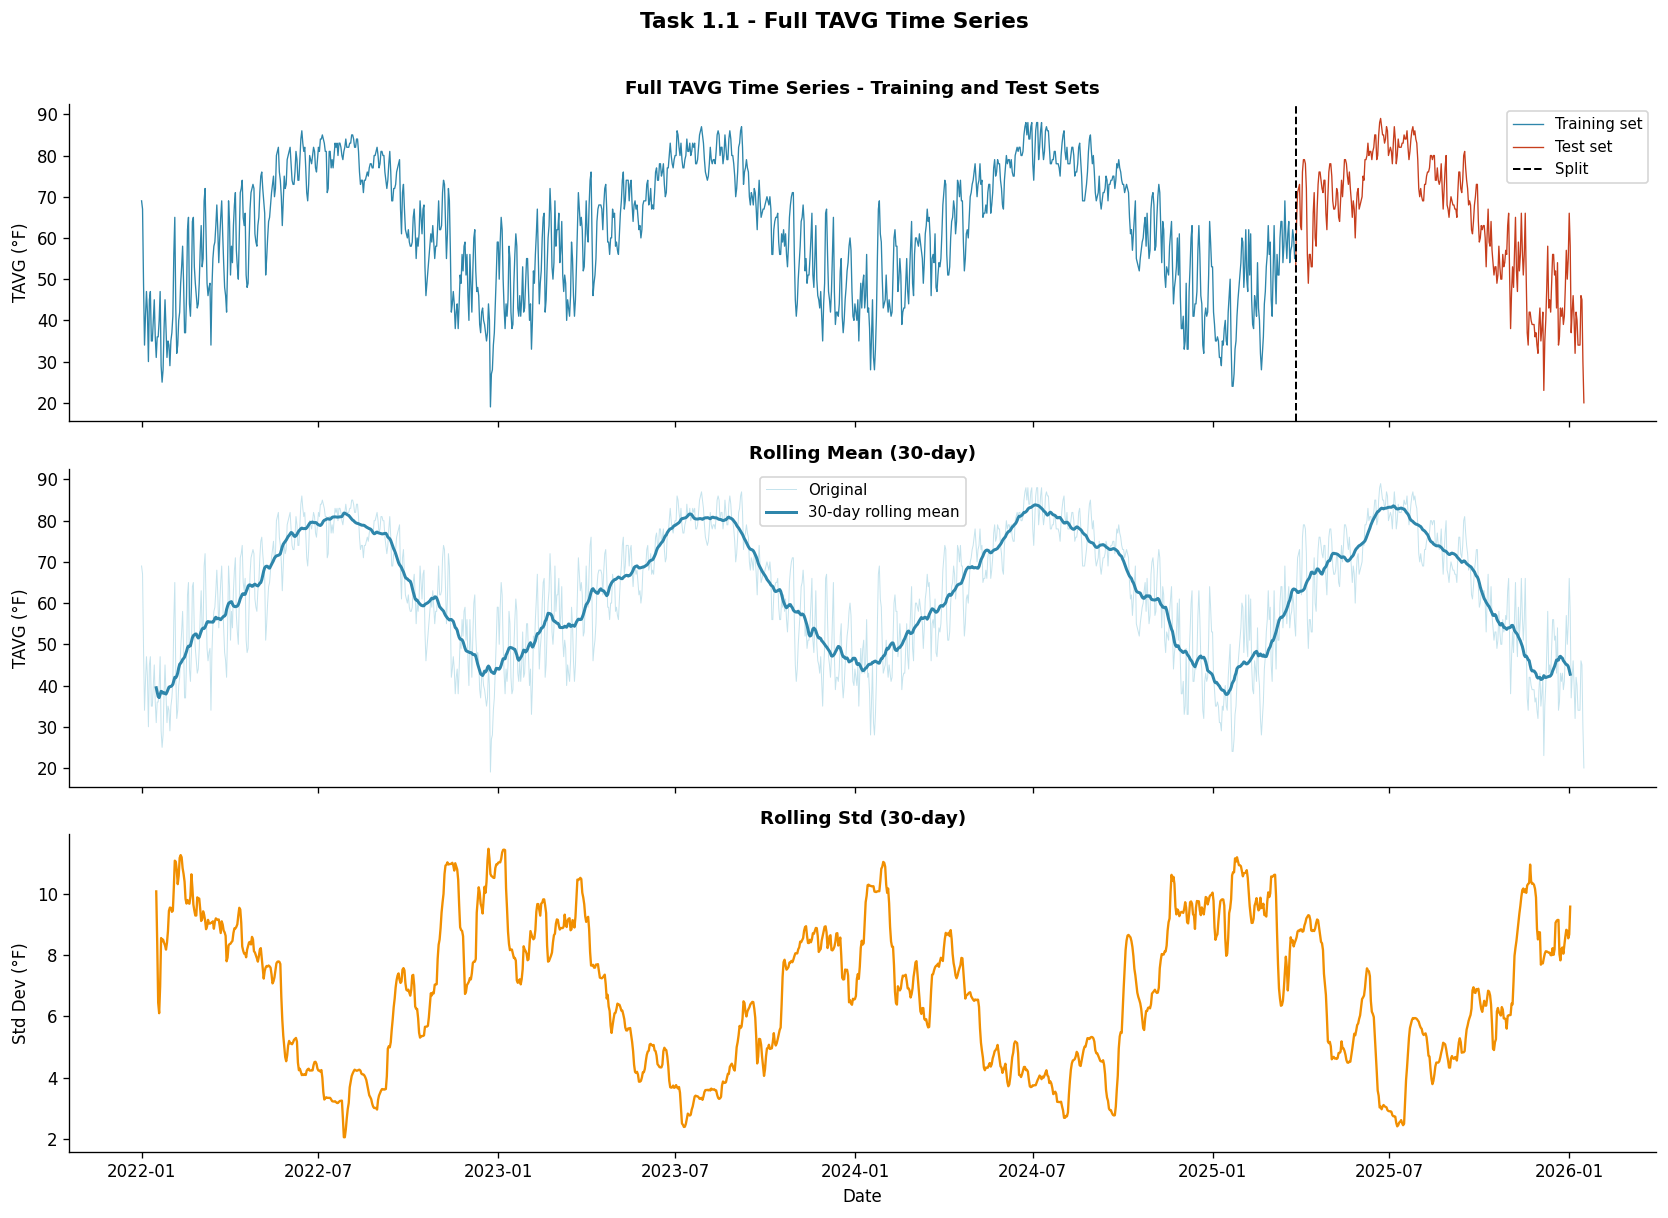

ADF statistic : -2.1367
p-value       : 0.2300
Critical vals : {'1%': np.float64(-3.434836872962171), '5%': np.float64(-2.863521656701378), '10%': np.float64(-2.567825016419591)}
Verdict       : Non-stationary
Note: visual inspection of rolling mean confirms strong seasonal non-stationarity.


In [35]:
roll_mean = ts.rolling(window=30, center=True).mean()
roll_std  = ts.rolling(window=30, center=True).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ts_train.index, train_vals, color='#2E86AB', linewidth=0.8, label='Training set')
axes[0].plot(ts_test.index,  test_vals,  color='#C73E1D', linewidth=0.8, label='Test set')
axes[0].axvline(ts_test.index[0], color='black', linestyle='--', linewidth=1.2, label='Split')
axes[0].set_ylabel('TAVG (°F)')
axes[0].set_title('Full TAVG Time Series - Training and Test Sets', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(ts.index, y,color='lightblue', linewidth=0.6, alpha=0.7, label='Original')
axes[1].plot(roll_mean.index, roll_mean, color='#2E86AB', linewidth=1.8, label='30-day rolling mean')
axes[1].set_ylabel('TAVG (°F)')
axes[1].set_title('Rolling Mean (30-day)', fontweight='bold')
axes[1].legend(fontsize=9)

axes[2].plot(roll_std.index, roll_std, color='#F18F01', linewidth=1.4)
axes[2].set_ylabel('Std Dev (°F)')
axes[2].set_title('Rolling Std (30-day)', fontweight='bold')
axes[2].set_xlabel('Date')

fig.suptitle('Task 1.1 - Full TAVG Time Series', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t1_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

adf = adfuller(ts.dropna())
print(f'ADF statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.4f}')
print(f'Critical vals : {adf[4]}')
verdict = 'Stationary (ADF)' if adf[1] < 0.05 else 'Non-stationary'
print(f'Verdict       : {verdict}')
print('Note: visual inspection of rolling mean confirms strong seasonal non-stationarity.')


## Task 1.2 - Trend, Variance, Seasonality

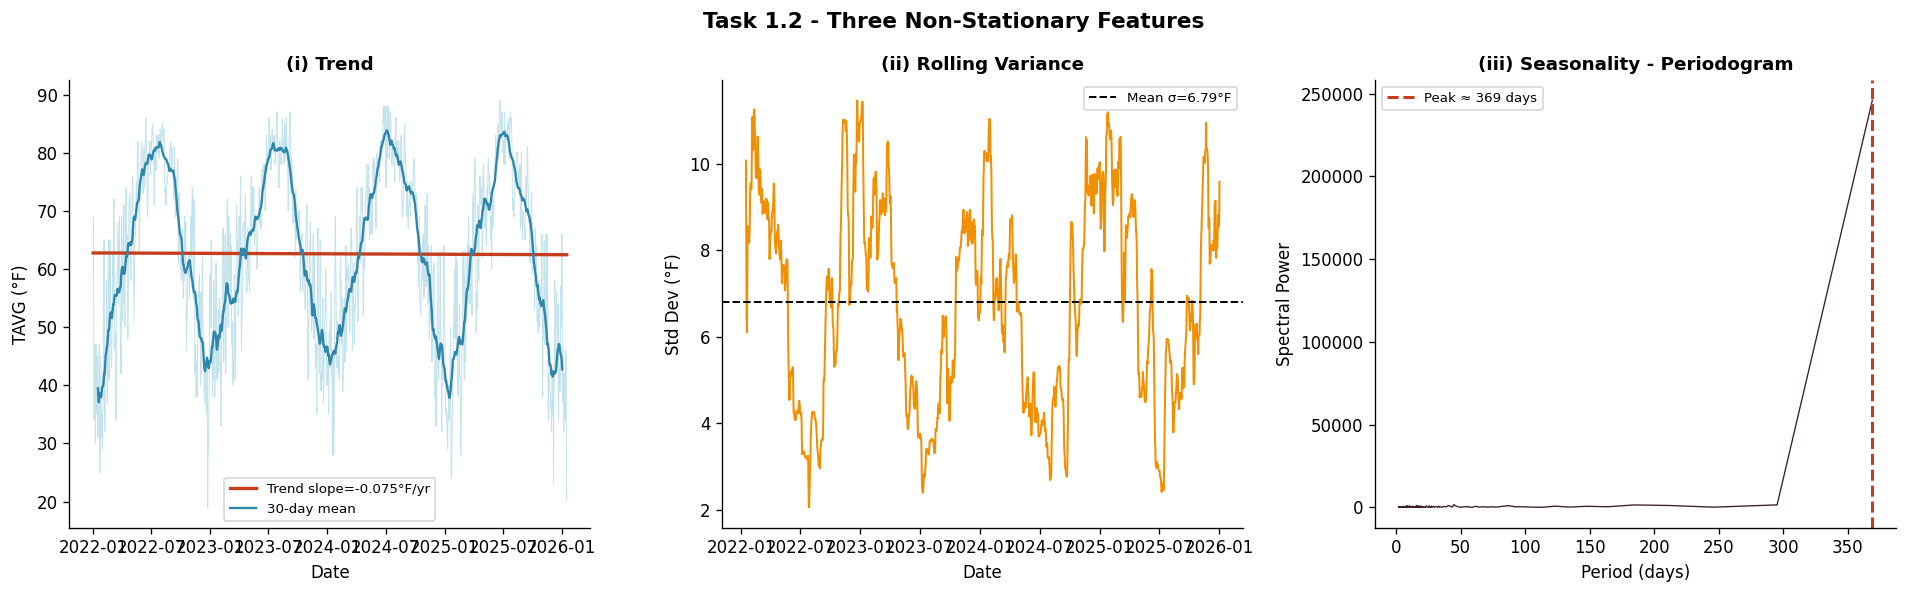

Dominant seasonal period: 369 days ≈ 1.01 years
Trend slope: -0.0753 °F/year


In [31]:
from scipy.signal import periodogram

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trend
t_idx = np.arange(len(ts))
coeffs = np.polyfit(t_idx, y, 1)
axes[0].plot(ts.index, y, color='lightblue', linewidth=0.6, alpha=0.7)
axes[0].plot(ts.index, np.polyval(coeffs, t_idx), color='#C73E1D', linewidth=2,
             label=f'Trend slope={coeffs[0]*365:.3f}°F/yr')
axes[0].plot(roll_mean.index, roll_mean, color='#2E86AB', linewidth=1.4, label='30-day mean')
axes[0].set_title('(i) Trend', fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('TAVG (°F)')
axes[0].legend(fontsize=8)

# Variance
axes[1].plot(roll_std.index, roll_std, color='#F18F01', linewidth=1.2)
axes[1].axhline(roll_std.mean(), color='black', linestyle='--',
                linewidth=1.2, label=f'Mean σ={roll_std.mean():.2f}°F')
axes[1].set_title('(ii) Rolling Variance', fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Std Dev (°F)')
axes[1].legend(fontsize=8)

# Seasonality
freqs, power = periodogram(y)
with np.errstate(divide='ignore'):
    periods = np.where(freqs > 0, 1.0/freqs, np.inf)
mask_p = (periods < 400) & (periods > 1)
axes[2].plot(periods[mask_p], power[mask_p], color='#3B1F2B', linewidth=0.8)
peak_per = periods[mask_p][np.argmax(power[mask_p])]
axes[2].axvline(peak_per, color='#C73E1D', linestyle='--',
                linewidth=1.8, label=f'Peak ≈ {peak_per:.0f} days')
axes[2].set_title('(iii) Seasonality - Periodogram', fontweight='bold')
axes[2].set_xlabel('Period (days)'); axes[2].set_ylabel('Spectral Power')
axes[2].legend(fontsize=8)

fig.suptitle('Task 1.2 - Three Non-Stationary Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_nonstationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dominant seasonal period: {peak_per:.0f} days ≈ {peak_per/365:.2f} years')
print(f'Trend slope: {coeffs[0]*365:.4f} °F/year')


## Task 1.3 - Transformations for Stationarity

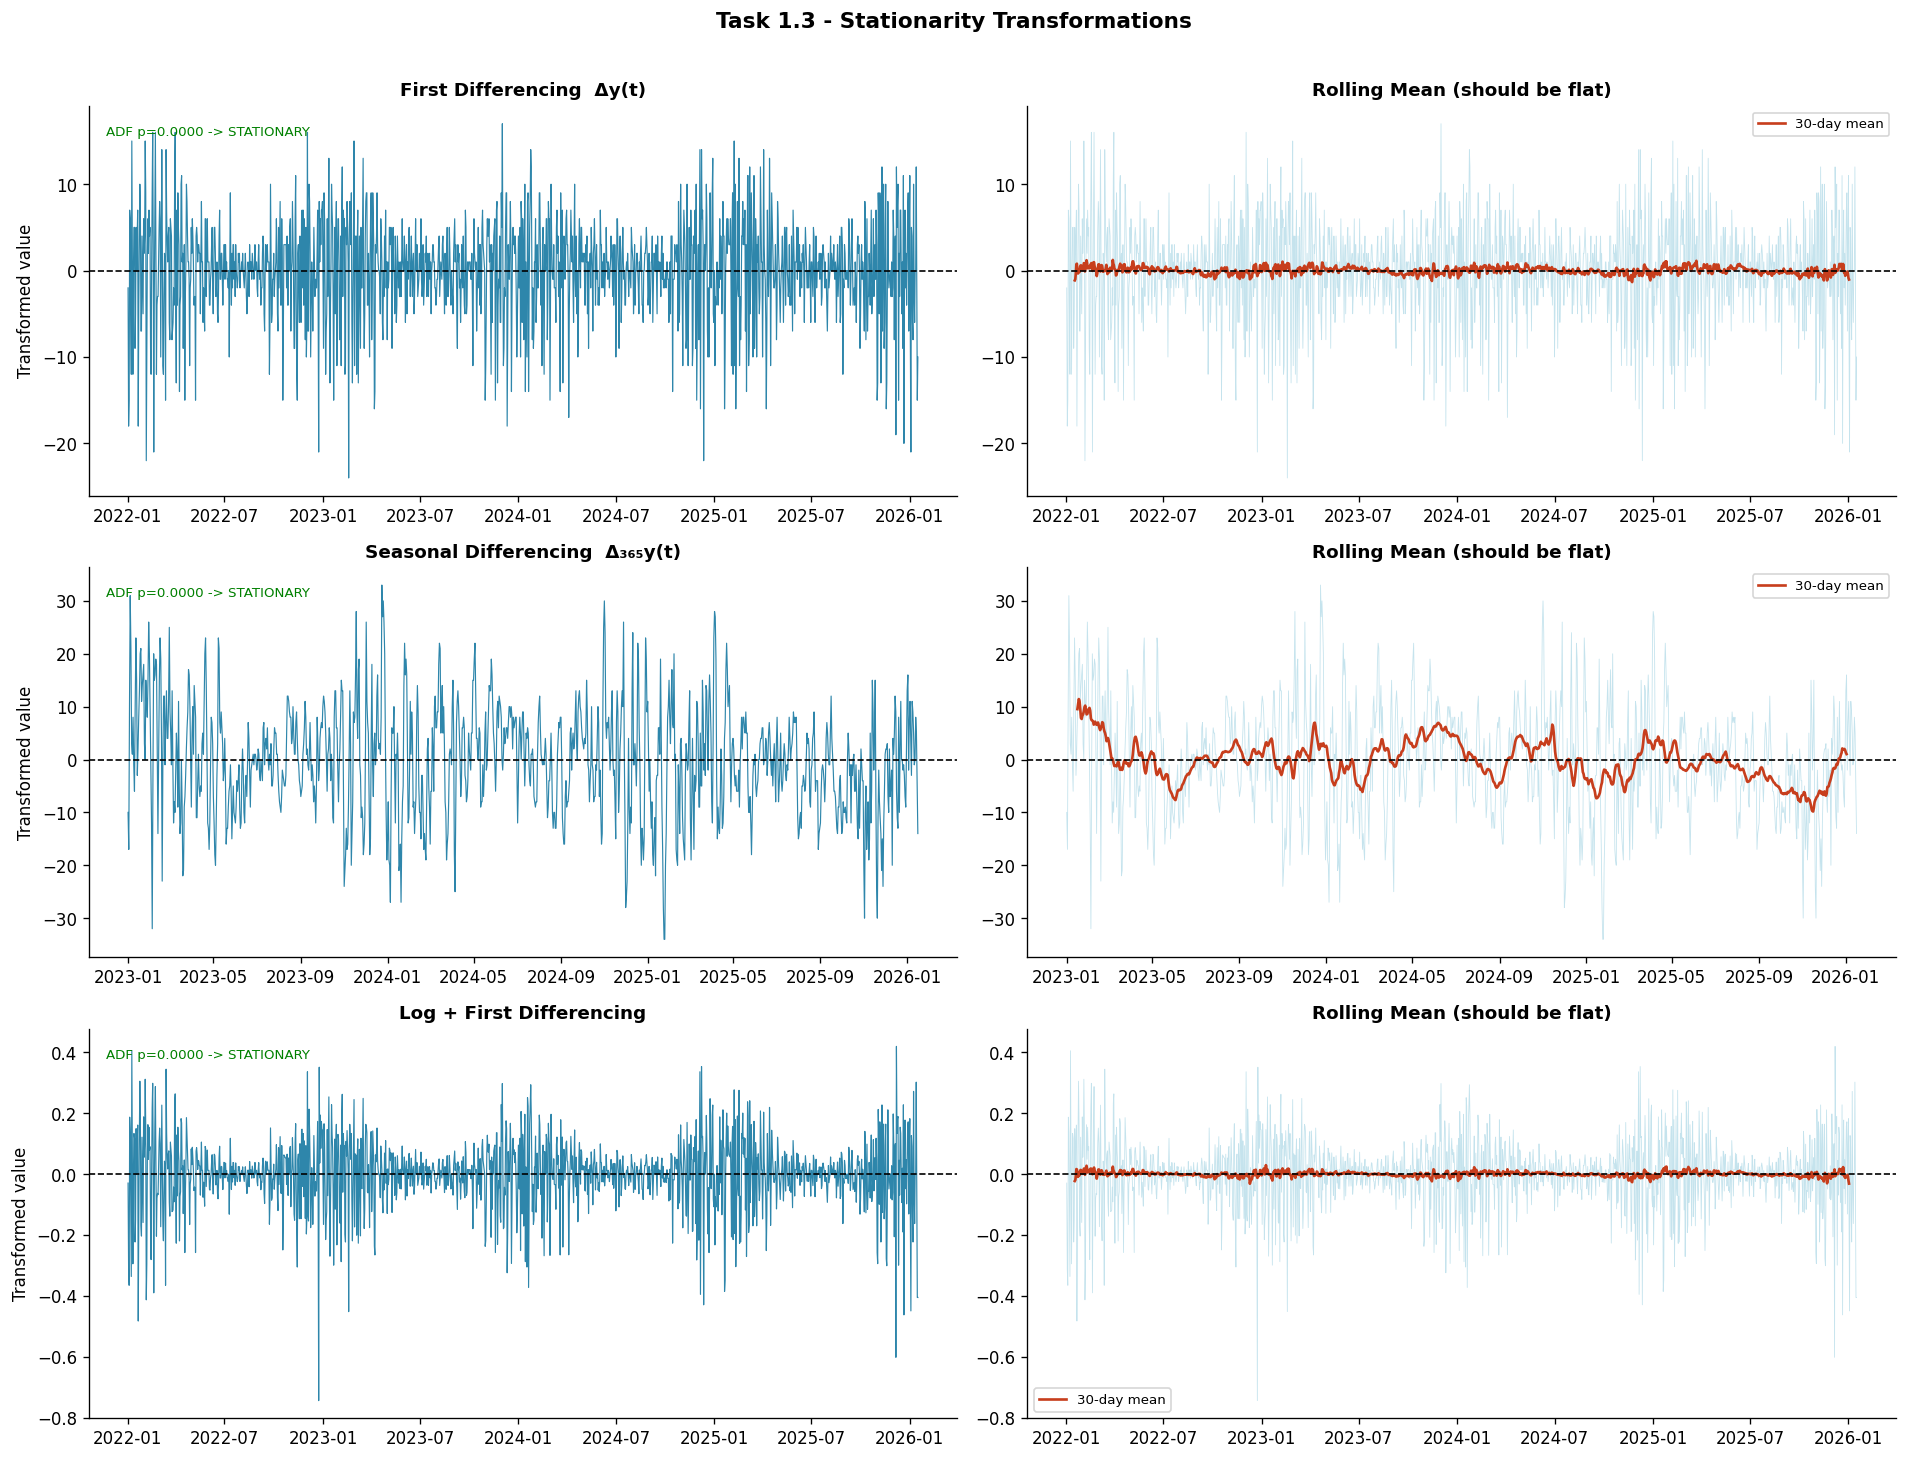

ADF results after transformation:
  First diff          : p=0.000000  -> Stationary  
  Seasonal diff       : p=0.000000  -> Stationary  
  Log+diff            : p=0.000000  -> Stationary  


In [32]:
ts_diff1     = ts.diff().dropna()
ts_sdiff     = ts.diff(365).dropna()
ts_log_diff  = np.log(ts.clip(lower=0.01)).diff().dropna()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
transforms = [
    (ts_diff1,    'First Differencing  Δy(t)'),
    (ts_sdiff,    'Seasonal Differencing  Δ₃₆₅y(t)'),
    (ts_log_diff, 'Log + First Differencing'),
]
for i, (series, title) in enumerate(transforms):
    axes[i,0].plot(series.index, series.values, color='#2E86AB', linewidth=0.7)
    axes[i,0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[i,0].set_title(title, fontweight='bold')
    axes[i,0].set_ylabel('Transformed value')
    rm = series.rolling(30, center=True).mean()
    axes[i,1].plot(series.index, series.values, color='lightblue', linewidth=0.5, alpha=0.7)
    axes[i,1].plot(rm.index, rm, color='#C73E1D', linewidth=1.6, label='30-day mean')
    axes[i,1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[i,1].set_title('Rolling Mean (should be flat)', fontweight='bold')
    axes[i,1].legend(fontsize=8)
    adf = adfuller(series.dropna())
    result = 'STATIONARY  ' if adf[1] < 0.05 else 'NON-STATIONARY '
    color  = 'green' if adf[1] < 0.05 else 'red'
    axes[i,0].text(0.02, 0.95, f'ADF p={adf[1]:.4f} -> {result}',
                   transform=axes[i,0].transAxes, fontsize=8, color=color, va='top')

fig.suptitle('Task 1.3 - Stationarity Transformations', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t1_transformations.png', dpi=150, bbox_inches='tight')
plt.show()

print('ADF results after transformation:')
for series, name in [(ts_diff1,'First diff'),(ts_sdiff,'Seasonal diff'),(ts_log_diff,'Log+diff')]:
    adf = adfuller(series.dropna())
    print(f'  {name:<20}: p={adf[1]:.6f}  -> {"Stationary  " if adf[1]<0.05 else "Non-stationary "}')


## Analysis

**Stationarity verdict:** The TAVG time series is **non-stationary**. The rolling mean oscillates between ~38°F (winter) and ~84°F (summer) every year, confirming a strong annual seasonal pattern. The rolling standard deviation also varies - winter months show higher day-to-day variability (~10–11°F) than summer months (~3–4°F), indicating non-constant variance.

**Three non-stationary features:**
- **(i) Trend:** A near-flat long-term linear trend but a dominant annual sinusoidal seasonal trend. Rolling mean clearly cycles with ~365-day period.
- **(ii) Variance:** Rolling std peaks in winter and troughs in summer, confirming seasonal heteroscedasticity.
- **(iii) Seasonality:** Periodogram shows a sharp dominant peak at ~365 days, confirming annual seasonality.

**Transformations:** All three transformations yield ADF p << 0.05, confirming stationarity is achieved. First differencing is the preferred transformation for AR modeling - it is the simplest and most interpretable.

The time series is not strictly stationary as the mean changes over time due to seasonal patterns in temperature. This is expected for real-world weather data.
